In [36]:
import numpy as np
import matplotlib.pyplot as plt
import qls
from molecules import CaOH, CaH, mu_N, gI
from scipy.constants import h, k
%matplotlib inline

### qls.States

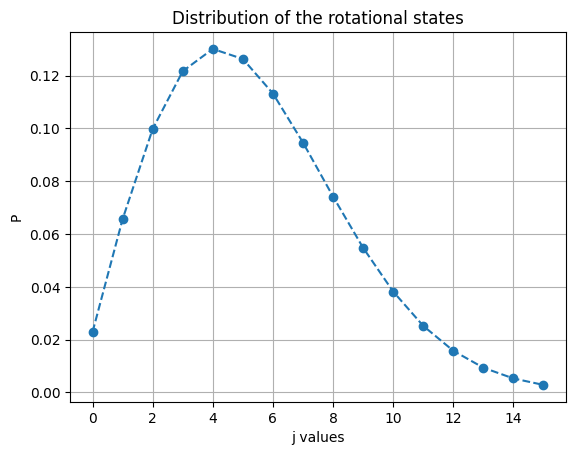

In [2]:
cah = CaH.from_file(b_field_gauss=6.5, j_max=15)
states = qls.States(cah, 300)
plt.plot(np.arange(cah.j_max+1), states.j_distribution(), linestyle = "--", marker = "o")
plt.xlabel("j values")
plt.ylabel("P")
plt.title("Distribution of the rotational states")
plt.grid()
plt.show()
plt.close()

In [3]:
# Check total probability

total_prob = np.sum(states.j_distribution())
print(total_prob)

0.9999999999999998


## Reproducing Chou et al. (2017)

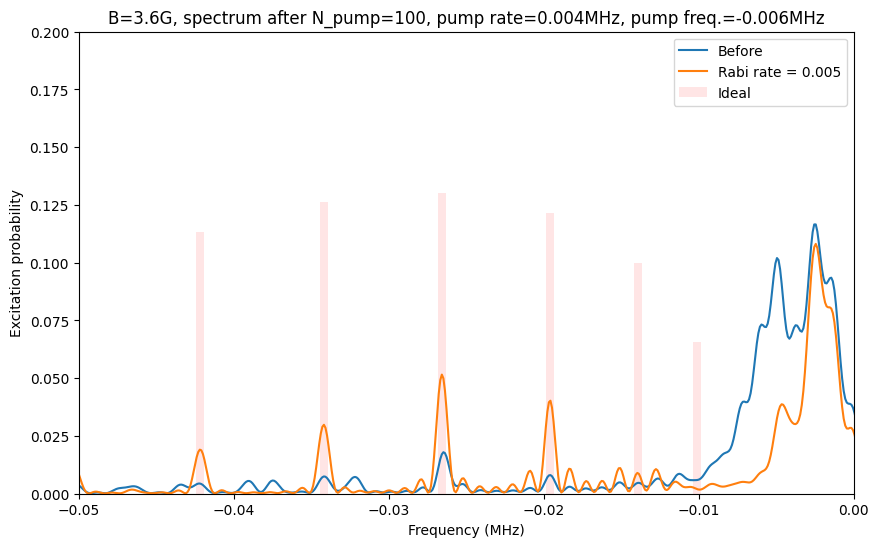

In [32]:
b_field_gauss = 3.6
j_max = 15

# I compute the molecule 
cah1 = CaH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)


temperature = 300
# I compute the states1. I do so because i need states1.dist,          J|m|csi|...|states1.dist
                                                                    #  .|.| . |   |     .
                                                                    #  .|.| . |   |     .
                                                                    #  .|.| . |   |     .

states1 = qls.States(cah1, temperature)

# len(states1.dist) = len(cah1.states_df)

# I take the transition_df. For each j (multiplet), i take the energy difference of the target distribution.
signature_transitions = np.array([cah1.transition_df.loc[cah1.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(cah1.j_max+1)])


# Then I apply the external pulse
duration_us = 1000.0
rabi_rate_mhz = 2*np.pi*0.005
max_frequency_mhz = 0.05
scan_points = 1000
dephased = False
is_minus = True

# get_spectrum: it takes excitation probability (from get_excitation_probabilities) + states1.dist distribution (from States) and np.dot @ freq.
# Then repeats for the frequencies and returns both the frequencies and the results @ each freq.
# This returns the spectrum before pumping.
frequencies, exc_probs1_before = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

# Then I pump the system n times to improve the population
pump_frequency_mhz = -0.006
num_pumps = 100
pump_dephased = True
pump_rabi_rate_mhz = 2*np.pi*0.004
pump_duration_us = 1000.0


# I update the state distribution (@ fixed j) with the exctiation matrix.
# I pump the system multiple times in order to better populate the molecule

for _ in range(num_pumps):
    states1.dist += qls.excitation_matrix(cah1, pump_frequency_mhz, pump_duration_us, pump_rabi_rate_mhz, pump_dephased, is_minus).dot(states1.dist)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, exc_probs1_before, label = "Before")     # Plot before

frequencies, exc_probs1_after = qls.get_spectrum(cah1, states1.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

ax.plot(frequencies, exc_probs1_after, label = f"Rabi rate = {rabi_rate_mhz/(2*np.pi):.3f}")      # Plot after
ax.bar(signature_transitions, states1.j_distribution(), color="red", width=0.0005, alpha=0.1, label = "Ideal")
ax.legend()
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Excitation probability")
ax.set_title(f"B={b_field_gauss}G, spectrum after N_pump={num_pumps}, pump rate={pump_rabi_rate_mhz/(2*np.pi):.3f}MHz, pump freq.={pump_frequency_mhz}MHz")
ax.set_xlim([-max_frequency_mhz, 0])
ax.set_ylim([0, 0.2])
plt.show()

# CaOH

## molecule info

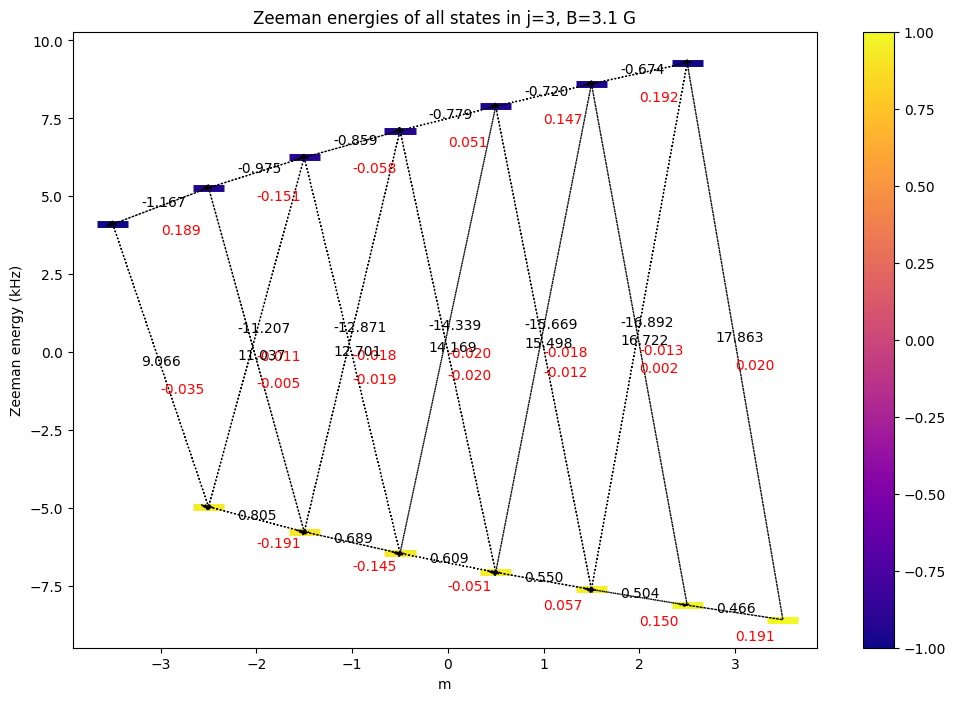

In [41]:
caoh = CaOH.from_file(b_field_gauss=3.1, j_max=50)

caoh.plot_zeeman_levels(3)

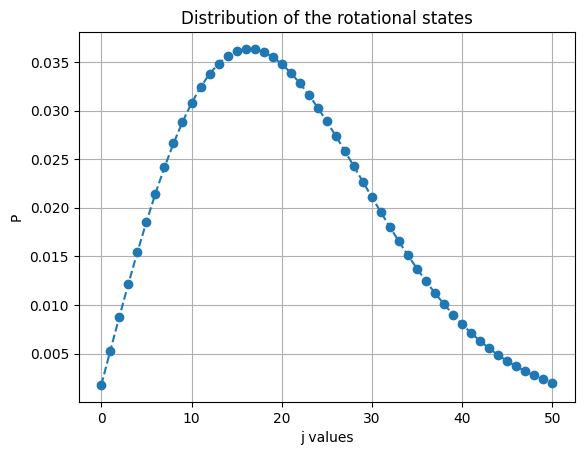

In [44]:
temperature = 300

states = qls.States(caoh, temperature)

# plt.bar(np.arange(caoh.j_max+1), states.j_distribution())
# plt.show()


plt.plot(np.arange(caoh.j_max+1), states.j_distribution(), linestyle = "--", marker = "o")
plt.xlabel("j values")
plt.ylabel("P")
plt.title("Distribution of the rotational states")
plt.grid()
plt.show()


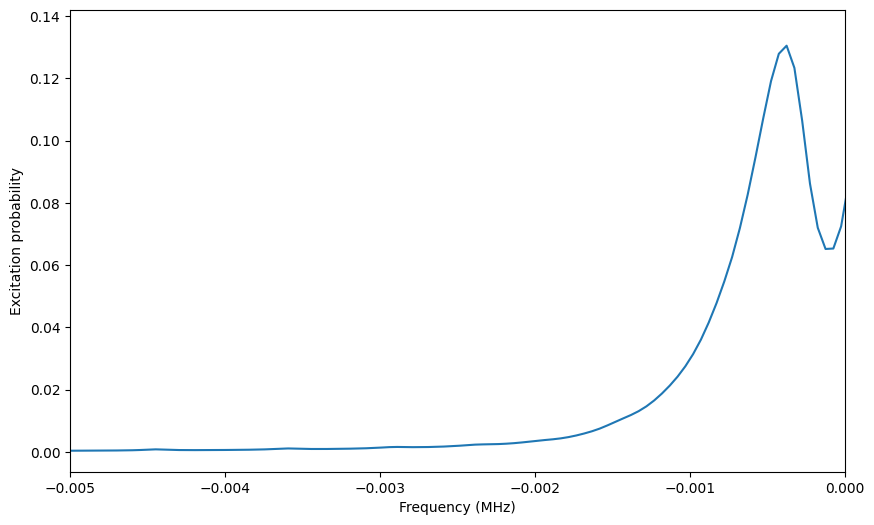

In [58]:
b_field_gauss = 3.6
j_max = 50

caoh = CaOH.from_file(b_field_gauss=b_field_gauss, j_max=j_max)

temperature = 300
states = qls.States(caoh, temperature)


signature_transitions = np.array([caoh.transition_df.loc[caoh.transition_df["j"]==j].iloc[0]["energy_diff"] * 1e-3 for j in range(caoh.j_max+1)])


duration_us = 1500.0
rabi_rate_mhz = 2*np.pi*0.001
max_frequency_mhz = 0.005
scan_points = 200
dephased = True
is_minus = True


frequencies, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frequencies, exc_probs, label = "Before") 


# frequencies = np.linspace(-max_frequency_mhz, max_frequency_mhz, scan_points)

# b_fields_gauss = [2.0, 3.1, 5.0, 10.0]
# colors = ["blue", "orange", "green", "red"]

# # gj = caoh.gj
# gj = -0.036

# for b, color in zip(b_fields_gauss, colors):
#     caoh = CaOH.from_file(b_field_gauss=b, j_max=50)
#     states = qls.States(caoh, temperature)
#     j_peak = np.argmax(states.j_distribution())
#     peak_minus = - caoh.cb_khz * gj - ( caoh.cij_khz * caoh.cb_khz * (gj-gI) ) / ( 2 * np.sqrt(caoh.cij_khz**2 * (j_peak + 0.5)**2 + (caoh.cb_khz * (gj - gI))**2 ) )
#     peak_plus = - caoh.cb_khz * gj + ( caoh.cij_khz * caoh.cb_khz * (gj-gI) ) / ( 2 * np.sqrt(caoh.cij_khz**2 * (j_peak + 0.5)**2 + (caoh.cb_khz * (gj - gI))**2 ) )
#     _, exc_probs = qls.get_spectrum(caoh, states.dist, duration_us, rabi_rate_mhz, max_frequency_mhz, scan_points, dephased, is_minus)
#     plt.plot(frequencies, exc_probs, color=color, label=f"B={b}G")
#     plt.vlines([-peak_minus * 1e-3, -peak_plus * 1e-3], 0, 0.3, color=color, linestyles="dashed")
# plt.legend()
plt.xlabel("Frequency (MHz)")
plt.ylabel("Excitation probability")
plt.xlim([-max_frequency_mhz, 0])
# plt.yscale("log")
plt.show()

In [55]:
# get the J value at maximum population
j_peak = np.argmax(states.j_distribution())

print(j_peak)

peak_minus = - caoh.cb_khz * caoh.gj - ( caoh.cij_khz * caoh.cb_khz * (caoh.gj-gI) ) / ( 2 * np.sqrt(caoh.cij_khz**2 * (j_peak + 0.5)**2 + (caoh.cb_khz * (caoh.gj - gI))**2 ) )
peak_plus = - caoh.cb_khz * caoh.gj + ( caoh.cij_khz * caoh.cb_khz * (caoh.gj-gI) ) / ( 2 * np.sqrt(caoh.cij_khz**2 * (j_peak + 0.5)**2 + (caoh.cb_khz * (caoh.gj - gI))**2 ) )
print(f"Pump frequency for J={j_peak} peak: {peak_minus:.2f}MHz, {peak_plus:.2f}MHz")

16
